In [1]:
import os
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
os.chdir('../')

In [3]:
from main.NeuralNet import NeuralNet

In [4]:
df = pd.read_csv('data/Titanic-Dataset.csv', sep=',')

### 1. Análise Exploratória

dataframe geral

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print(df.shape)

(891, 12)


In [7]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
print(df.duplicated().sum())

0


por coluna

In [10]:
# Label
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [11]:
print(df['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


In [12]:
print(df['SibSp'].value_counts())

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


In [13]:
print(df['Parch'].value_counts())

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [14]:
print(df['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


histogramas

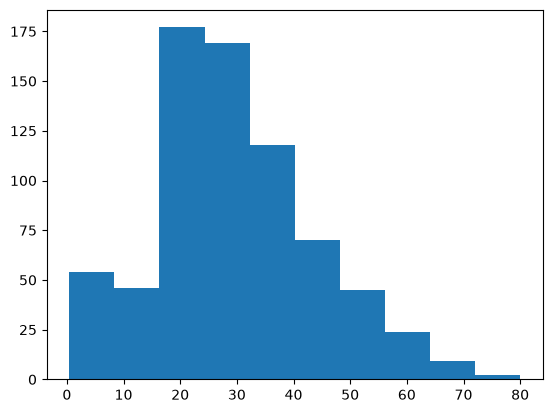

In [15]:
plt.hist(df['Age'])
plt.show()

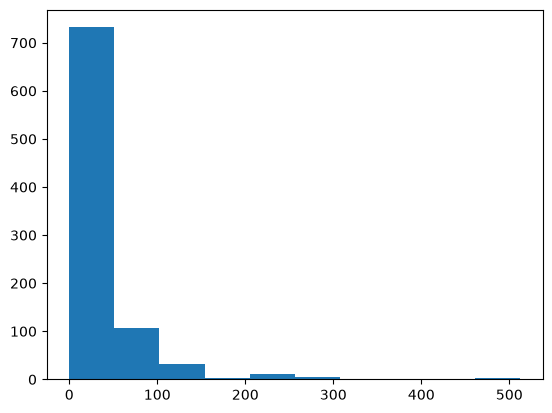

In [16]:
plt.hist(df['Fare'])
plt.show()

outliers

In [17]:
# Coluna Age
age_Q1 = df['Age'].quantile(0.25)
age_Q3 = df['Age'].quantile(0.75)

print(age_Q1, age_Q3)

20.125 38.0


In [18]:
age_IQR = age_Q3 - age_Q1
print(age_IQR)

17.875


In [19]:
lower_limit = age_Q1 - 1.5*age_IQR  # limite mínimo para o primeiro quartil
upper_limit = age_Q3 + 1.5*age_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-6.6875 64.8125


In [20]:
outliers_age = (df['Age'] < lower_limit) | (df['Age'] > upper_limit)
print(outliers_age.sum())

11


In [21]:
# Coluna Fare
fare_Q1 = df['Fare'].quantile(0.25)
fare_Q3 = df['Fare'].quantile(0.75)

print(fare_Q1, fare_Q3)

7.9104 31.0


In [22]:
fare_IQR = fare_Q3 - fare_Q1
print(fare_IQR)

23.0896


In [23]:
lower_limit = fare_Q1 - 1.5*fare_IQR  # limite mínimo para o primeiro quartil
upper_limit = fare_Q3 + 1.5*fare_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-26.724 65.6344


In [24]:
outliers_fare = (df['Fare'] < lower_limit) | (df['Fare'] > upper_limit)
print(outliers_fare.sum())

116


### 2. Train-Test Split

In [25]:
X_data = df.drop(columns=['Survived'])
y_data = df['Survived']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

### Conjunto de Treino

#### 3.1. Tratamento de Outliers

In [27]:
# Coluna Age
age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

print(age_Q1, age_Q3)

20.0 38.0


In [28]:
age_IQR = age_Q3 - age_Q1
print(age_IQR)

18.0


In [29]:
lower_limit = age_Q1 - 1.5*age_IQR  # limite mínimo para o primeiro quartil
upper_limit = age_Q3 + 1.5*age_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-7.0 65.0


In [30]:
outliers_age = (X_train['Age'] < lower_limit) | (X_train['Age'] > upper_limit)
print(outliers_age.sum())

5


In [31]:
X_train = X_train[(X_train['Age'] > lower_limit) & (X_train['Age'] < upper_limit)]

In [32]:
y_train = y_train.loc[X_train.index]

In [33]:
# Coluna Fare
fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

print(fare_Q1, fare_Q3)

8.05 34.375


In [34]:
fare_IQR = fare_Q3 - fare_Q1
print(fare_IQR)

26.325


In [35]:
lower_limit = fare_Q1 - 1.5*fare_IQR  # limite mínimo para o primeiro quartil
upper_limit = fare_Q3 + 1.5*fare_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-31.437499999999996 73.8625


In [36]:
outliers_fare = (X_train['Fare'] < lower_limit) | (X_train['Fare'] > upper_limit)
print(outliers_fare.sum())

60


In [37]:
X_train = X_train[(X_train['Fare'] > lower_limit) & (X_train['Fare'] < upper_limit)]

In [38]:
y_train = y_train.loc[X_train.index]

### 4. Transformação

#### 4.1. Transformações iniciais

Remoção de colunas "inuteis"

In [39]:
X_train = X_train.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket', 'Embarked'])

In [40]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
172,3,female,1.0,1,1,11.1333
450,2,male,36.0,1,2,27.7500
314,2,male,43.0,1,1,26.2500
801,2,female,31.0,1,1,26.2500
90,3,male,29.0,0,0,8.0500


#### 4.2. Codificação de Variáveis Categóricas

one hot encoder

In [41]:
# Inicializa o codificador OneHotEncoder para transformar variáveis categóricas em numéri
ohe_encoder = OneHotEncoder(sparse_output=False)
# Define a lista de colunas categóricas a serem codificadas
categorical_columns = ['Sex']
# Aplica a codificação One-Hot nas colunas categóricas do conjunto de treinamento
encoded_data = ohe_encoder.fit_transform(X_train[categorical_columns])
# Obtém os nomes das novas colunas geradas pela codificação
new_columns = ohe_encoder.get_feature_names_out(categorical_columns)
# Cria um DataFrame com os dados codificados e os novos nomes de colunas
df_ohe = pd.DataFrame(encoded_data, columns=new_columns)
# Remove as colunas categóricas originais do conjunto de treinamento
df_not_ohe = X_train.drop(columns=categorical_columns).reset_index(drop=True)
# Concatena o DataFrame com as colunas codificadas ao DataFrame original
X_train = pd.concat([df_not_ohe, df_ohe], axis=1)
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,3,1.0,1,1,11.1333,1.0,0.0
1,2,36.0,1,2,27.7500,0.0,1.0
2,2,43.0,1,1,26.2500,0.0,1.0
3,2,31.0,1,1,26.2500,1.0,0.0
4,3,29.0,0,0,8.0500,0.0,1.0
...,...,...,...,...,...,...,...
429,3,35.0,0,0,8.0500,0.0,1.0
430,2,35.0,0,0,26.0000,0.0,1.0
431,3,16.0,5,2,46.9000,1.0,0.0
432,3,21.0,0,0,7.6500,1.0,0.0


#### 4.3. Transformações Finais

normalização/padronização

In [42]:
scaler = StandardScaler()

In [43]:
scaler.fit(X_train)

StandardScaler()

In [44]:
X_train.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male'], dtype='str')

In [45]:
colunas_numericas = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male']

In [46]:
# Substitui os valores originais pelas colunas padronizadas
X_train[colunas_numericas] = scaler.transform(X_train[colunas_numericas])
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,0.767528,-1.973012,0.450209,0.704950,-0.556657,1.433994,-1.433994
1,-0.614659,0.583414,0.450209,1.890795,0.508848,-0.697353,0.697353
2,-0.614659,1.094699,0.450209,0.704950,0.412664,-0.697353,0.697353
3,-0.614659,0.218210,0.450209,0.704950,0.412664,1.433994,-1.433994
4,0.767528,0.072129,-0.536613,-0.480896,-0.754366,-0.697353,0.697353
...,...,...,...,...,...,...,...
429,0.767528,0.510373,-0.536613,-0.480896,-0.754366,-0.697353,0.697353
430,-0.614659,0.510373,-0.536613,-0.480896,0.396633,-0.697353,0.697353
431,0.767528,-0.877401,4.397499,1.890795,1.736795,1.433994,-1.433994
432,0.767528,-0.512197,-0.536613,-0.480896,-0.780015,1.433994,-1.433994


resampling

In [47]:
y_train.value_counts()

Survived
0    280
1    154
Name: count, dtype: int64

In [48]:
# Aplica SMOTE - Oversampling sintético
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [49]:
y_train.value_counts()

Survived
1    280
0    280
Name: count, dtype: int64

### Conjunto de Teste

### 3. Pré-processamento

#### 3.1. Tratamento de outliers

In [50]:
# Coluna Age
age_Q1 = X_test['Age'].quantile(0.25)
age_Q3 = X_test['Age'].quantile(0.75)

print(age_Q1, age_Q3)

21.0 38.5


In [51]:
age_IQR = age_Q3 - age_Q1
print(age_IQR)

17.5


In [52]:
lower_limit = age_Q1 - 1.5*age_IQR  # limite mínimo para o primeiro quartil
upper_limit = age_Q3 + 1.5*age_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-5.25 64.75


In [53]:
outliers_age = (X_test['Age'] < lower_limit) | (X_test['Age'] > upper_limit)
print(outliers_age.sum())

6


In [54]:
X_test = X_test[(X_test['Age'] > lower_limit) & (X_test['Age'] < upper_limit)]

In [55]:
y_test = y_test.loc[X_test.index]

In [56]:
# Coluna Fare
fare_Q1 = X_test['Fare'].quantile(0.25)
fare_Q3 = X_test['Fare'].quantile(0.75)

print(fare_Q1, fare_Q3)

8.05 31.275


In [57]:
fare_IQR = fare_Q3 - fare_Q1
print(fare_IQR)

23.224999999999998


In [58]:
lower_limit = fare_Q1 - 1.5*fare_IQR  # limite mínimo para o primeiro quartil
upper_limit = fare_Q3 + 1.5*fare_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-26.787499999999998 66.1125


In [59]:
outliers_fare = (X_test['Fare'] < lower_limit) | (X_test['Fare'] > upper_limit)
print(outliers_fare.sum())

31


In [60]:
X_test = X_test[(X_test['Fare'] > lower_limit) & (X_test['Fare'] < upper_limit)]

In [61]:
y_test = y_test.loc[X_test.index]

### 4. Transformação

### 4.1. Transformações iniciais

Remoção de colunas "inuteis"

In [62]:
X_test = X_test.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket', 'Embarked'])

In [63]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
439,2,male,31.0,0,0,10.5000
840,3,male,20.0,0,0,7.9250
720,2,female,6.0,0,1,33.0000
39,3,female,14.0,1,0,11.2417
333,3,male,16.0,2,0,18.0000


#### 4.2. Codificação de Variáveis Categóricas

one hot encoder

In [64]:
# Inicializa o codificador OneHotEncoder para transformar variáveis categóricas em numéri
ohe_encoder = OneHotEncoder(sparse_output=False)
# Define a lista de colunas categóricas a serem codificadas
categorical_columns = ['Sex']
# Aplica a codificação One-Hot nas colunas categóricas do conjunto de treinamento
encoded_data = ohe_encoder.fit_transform(X_test[categorical_columns])
# Obtém os nomes das novas colunas geradas pela codificação
new_columns = ohe_encoder.get_feature_names_out(categorical_columns)
# Cria um DataFrame com os dados codificados e os novos nomes de colunas
df_ohe = pd.DataFrame(encoded_data, columns=new_columns)
# Remove as colunas categóricas originais do conjunto de treinamento
df_not_ohe = X_test.drop(columns=categorical_columns).reset_index(drop=True)
# Concatena o DataFrame com as colunas codificadas ao DataFrame original
X_test = pd.concat([df_not_ohe, df_ohe], axis=1)
X_test

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,2,31.0,0,0,10.5000,0.0,1.0
1,3,20.0,0,0,7.9250,0.0,1.0
2,2,6.0,0,1,33.0000,1.0,0.0
3,3,14.0,1,0,11.2417,1.0,0.0
4,3,16.0,2,0,18.0000,0.0,1.0
...,...,...,...,...,...,...,...
173,2,29.0,1,0,26.0000,1.0,0.0
174,2,40.0,0,0,13.0000,1.0,0.0
175,3,27.0,0,0,8.6625,0.0,1.0
176,3,17.0,0,0,8.6625,0.0,1.0


#### 4.3. Transformações Finais

normalização/padronização

In [65]:
# Substitui os valores originais pelas colunas padronizadas
# Obs: deve-se utilizar o scaler ajustado com o dataset de TREINO
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])
X_test

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,-0.614659,0.218210,-0.536613,-0.480896,-0.597266,-0.697353,0.697353
1,0.767528,-0.585238,-0.536613,-0.480896,-0.762382,-0.697353,0.697353
2,-0.614659,-1.607808,-0.536613,0.704950,0.845491,1.433994,-1.433994
3,0.767528,-1.023482,0.450209,-0.480896,-0.549707,1.433994,-1.433994
4,0.767528,-0.877401,1.437032,-0.480896,-0.116347,-0.697353,0.697353
...,...,...,...,...,...,...,...
173,-0.614659,0.072129,0.450209,-0.480896,0.396633,1.433994,-1.433994
174,-0.614659,0.875577,-0.536613,-0.480896,-0.436960,1.433994,-1.433994
175,0.767528,-0.073953,-0.536613,-0.480896,-0.715091,-0.697353,0.697353
176,0.767528,-0.804360,-0.536613,-0.480896,-0.715091,-0.697353,0.697353


### 5. Treinamento

Pipeline de treinamento:
1. Modelo (input_size, hidden_size, output_size, ...)
2. Loss e Otimizador
3. Treinamento:
    - Forward pass
    - Calcula loss
    - Backward pass
    - Atualiza pesos

In [66]:
y_train.nunique()

2

1. Modelo

In [67]:
model = NeuralNet(input_size=len(X_train.columns), hidden_size=5, num_classes=1)

2. Loss e otimizador

In [68]:
learning_rate = 0.001

In [69]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

3. Treinamento do modelo

In [70]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [71]:
num_epochs = 100
for epoch in range(100):
    # Forward pass
    y_pred = model(X_train_tensor)

    # Calcula loss
    loss = criterion(y_pred, y_train_tensor.view(-1, 1))

    # Backward pass + Atualiza pesos
    loss.backward()

    # Updates
    optimizer.step()
    optimizer.zero_grad()